# Growth Model Implementation

In [13]:
import numpy as np
from scipy.ndimage import binary_dilation

def solve_sor(c, is_object, omega=1.8, epsilon=1e-4, max_iter=500):
    """
    Solves the Laplace equation using SOR.
    c: concentration grid
    is_object: boolean array (True where the sink/object is)
    """
    N = c.shape[0]
    for _ in range(max_iter):
        old_c = c.copy()
        for i in range(N):
            for j in range(1, N-1):
                if is_object[i, j]:
                    c[i, j] = 0
                    continue
                
                # Neighbors with periodic x-boundaries
                left = c[(i - 1) % N, j]
                right = c[(i + 1) % N, j]
                up = c[i, j + 1]
                down = c[i, j - 1]
                
                # SOR Update
                gs_val = 0.25 * (left + right + up + down)
                c[i, j] = omega * gs_val + (1 - omega) * c[i, j]
        
        c[c < 0] = 0 # Ensure non-negativity
        if np.max(np.abs(c - old_c)) < epsilon:
            break
    return c

def get_growth_candidates(is_object):
    """
    Identifies neighbors of the current cluster.
    """
    # Use dilation to find neighbors, then subtract the object itself
    struct = np.array([[0,1,0], [1,1,1], [0,1,0]])
    neighbors = binary_dilation(is_object, structure=struct)
    candidates_mask = neighbors & ~is_object
    
    # Exclude boundaries
    candidates_mask[:, 0] = False
    candidates_mask[:, -1] = False
    
    return np.argwhere(candidates_mask)

def run_dla(N=100, eta=1.0, omega=1.8, num_steps=50):
    # 1. Initialize Grids
    c = np.zeros((N, N))
    # Initial condition: linear gradient
    y_coords = np.linspace(0, 1, N)
    for j in range(N):
        c[:, j] = y_coords[j]
        
    is_object = np.zeros((N, N), dtype=bool)
    
    # 2. Add Initial Seed
    is_object[N//2, 0] = True 
    c[N//2, 0] = 0 
    
    for step in range(num_steps):
        # 3. Solve for concentration
        # Start from previous solution for efficiency 
        c = solve_sor(c, is_object, omega)
        
        # 4. Identify candidates 
        candidates = get_growth_candidates(is_object)
        
        # 5. Calculate probabilities p_g
        candidate_conc = np.array([c[coord[0], coord[1]] for coord in candidates])
        weights = candidate_conc**eta
        probs = weights / np.sum(weights)
        
        # 6. Select and grow
        chosen_idx = np.random.choice(len(candidates), p=probs)
        new_point = candidates[chosen_idx]
        
        is_object[new_point[0], new_point[1]] = True
        c[new_point[0], new_point[1]] = 0 # New part of sink
        
        if step % 10 == 0:
            print(f"Growth step {step} complete.")
            
    return is_object, c


$\eta$ Parameter Investigation

In [14]:
import matplotlib.pyplot as plt

def grow_dla_cluster(N=100, eta=1.0, num_particles=150, omega=1.8):
    """Simulates growth for a specific eta value."""
    c = np.zeros((N, N))
    # Initialize with linear gradient
    for j in range(N):
        c[:, j] = j / (N - 1)
        
    is_object = np.zeros((N, N), dtype=bool)
    is_object[N//2, 0] = True # Initial seed
    
    for _ in range(num_particles):
        # Pass omega
        c = solve_sor(c, is_object, omega=omega)
        
        # Identify growth candidates
        struct = np.array([[0,1,0], [1,1,1], [0,1,0]])
        neighbors = binary_dilation(is_object, structure=struct)
        candidates_mask = neighbors & ~is_object
        candidates_mask[:, 0] = False 
        candidates_mask[:, -1] = False
        
        coords = np.argwhere(candidates_mask)
        if len(coords) == 0: break
            
        candidate_concs = np.array([c[coord[0], coord[1]] for coord in coords])
        
        # p_g ~ c^eta
        weights = (candidate_concs + 1e-9) ** eta
        probs = weights / np.sum(weights)
        
        chosen_idx = np.random.choice(len(coords), p=probs)
        new_node = coords[chosen_idx]
        is_object[new_node[0], new_node[1]] = True
        c[new_node[0], new_node[1]] = 0 
        
    return is_object


<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:10: SyntaxWarning: invalid escape sequence '\e'
C:\Users\sofro\AppData\Local\Temp\ipykernel_36440\1311544288.py:10: SyntaxWarning: invalid escape sequence '\e'
  ax.set_title(f"$\eta = {eta}$")


Simulating for eta = 0.0...
Simulating for eta = 1.0...
Simulating for eta = 4.0...


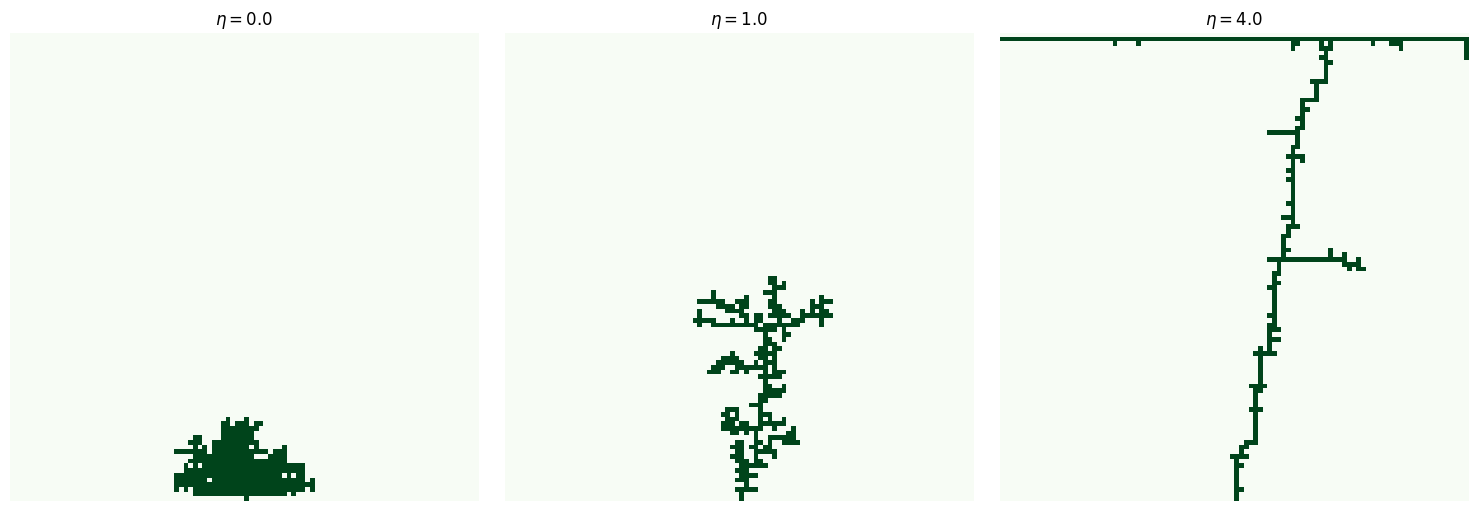

In [15]:
# Visualization
eta_values = [0.0, 1.0, 4.0]
N_size = 100
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, eta in zip(axes, eta_values):
    print(f"Simulating for eta = {eta}...")
    cluster = grow_dla_cluster(N=N_size, eta=eta, num_particles=300)
    ax.imshow(cluster.T, origin='lower', cmap='Greens')
    ax.set_title(f"$\eta = {eta}$")
    ax.axis('off')

plt.tight_layout()
plt.show()

SOR Performance Analysis

Analyzing Initial State ...
Generating cluster for Grown State test...
Testing Grown State ...
Empirical Optimal Omega (Empty): 1.94
Empirical Optimal Omega (Grown): 1.94


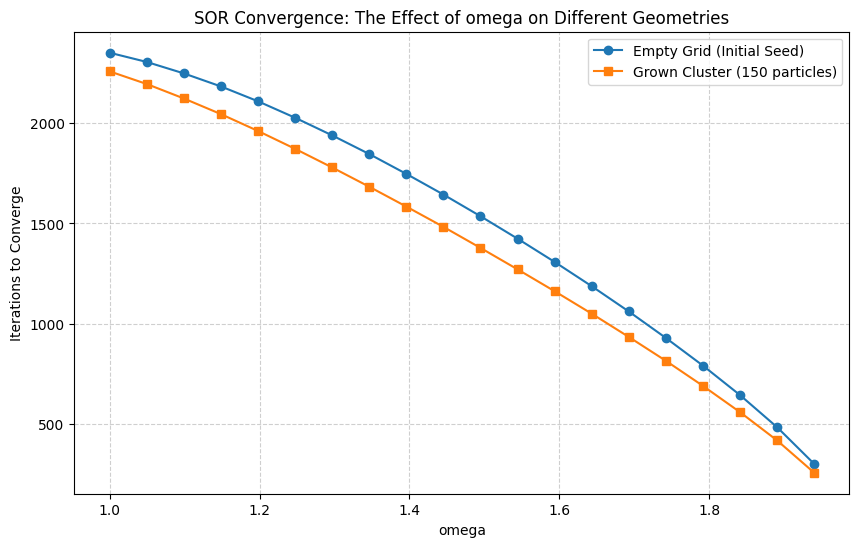

In [20]:
def solve_sor_monitored(c_input, is_object, omega, epsilon=1e-4, max_iter=5000):
    """
    SOR with the number of iterations saved.
    """
    c = c_input.copy()
    N = c.shape[0]
    iterations = 0
    
    for k in range(max_iter):
        iterations += 1
        old_c = c.copy()
        
        # SOR iteration with periodic x-boundaries
        for i in range(N):
            for j in range(1, N-1):
                if is_object[i, j]:
                    c[i, j] = 0
                    continue
                
                left = c[(i - 1) % N, j]
                right = c[(i + 1) % N, j]
                up = c[i, j + 1]
                down = c[i, j - 1]
                
                target = 0.25 * (left + right + up + down)
                c[i, j] = omega * target + (1 - omega) * c[i, j]

        c[c < 0] = 0
        if np.max(np.abs(c - old_c)) < epsilon:
            return c, iterations
            
    return c, max_iter

def get_grown_cluster(N, num_particles, eta=1.0):
    c = np.zeros((N, N))
    for j in range(N): c[:, j] = j / (N - 1)
    is_object = np.zeros((N, N), dtype=bool)
    is_object[N//2, 0] = True
    
    for _ in range(num_particles):
        c, _ = solve_sor_monitored(c, is_object, omega=1.7)
        struct = np.array([[0,1,0], [1,1,1], [0,1,0]])
        candidates = np.argwhere(binary_dilation(is_object, struct) & ~is_object)
        candidates = candidates[(candidates[:,1] > 0) & (candidates[:,1] < N-1)]
        
        if len(candidates) == 0: break
            
        # Weight Calculation
        candidate_concs = np.array([c[coord[0], coord[1]] for coord in candidates])
        # Add a tiny epsilon (1e-12) so weights are never zero or negative
        weights = (np.maximum(candidate_concs, 0) + 1e-12)**eta
        probs = weights / np.sum(weights)
        
        idx = np.random.choice(len(candidates), p=probs)
        is_object[candidates[idx][0], candidates[idx][1]] = True
        c[candidates[idx][0], candidates[idx][1]] = 0
        
    return c, is_object

# Performance Analysis
N = 100
omega_range = np.linspace(1.0, 1.94, 20)
results_initial = []
results_grown = []

# Define the grid: zeros everywhere, 1.0 at the top
c_cold_start = np.zeros((N, N))
c_cold_start[:, -1] = 1.0 

# 1. Test Initial State
print("Analyzing Initial State ...")
is_obj_init = np.zeros((N, N), dtype=bool)
is_obj_init[N//2, 0] = True

for w in omega_range:
    # We pass a copy of c_cold_start so each w starts from the same 'messy' state
    _, iters = solve_sor_monitored(c_cold_start.copy(), is_obj_init, omega=w)
    results_initial.append(iters)

# 2. Test Grown State
print("Generating cluster for Grown State test...")
_, is_obj_grown = get_grown_cluster(N, num_particles=150)

print("Testing Grown State ...")
for w in omega_range:
    # Use the same cold start grid so we can compare complexity
    _, iters = solve_sor_monitored(c_cold_start.copy(), is_obj_grown, omega=w)
    results_grown.append(iters)

# --- Visualization ---
plt.figure(figsize=(10, 6))
plt.plot(omega_range, results_initial, 'o-', label='Empty Grid (Initial Seed)')
plt.plot(omega_range, results_grown, 's-', label='Grown Cluster (150 particles)')

plt.xlabel(r'omega')
plt.ylabel('Iterations to Converge')
plt.title(r'SOR Convergence: The Effect of omega on Different Geometries')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Find and mark the empirical optimums
opt_w_init = omega_range[np.argmin(results_initial)]
opt_w_grown = omega_range[np.argmin(results_grown)]
print(f"Empirical Optimal Omega (Empty): {opt_w_init:.2f}")
print(f"Empirical Optimal Omega (Grown): {opt_w_grown:.2f}")

plt.show()

# Task B

In [22]:
import time
def solve_sor_vectorized(c, is_object, omega=1.8, epsilon=1e-4, max_iter=5000):
    """
    Optimized SOR using Red-Black Vectorization.
    """
    N = c.shape[0]
    
    # Create masks for the checkerboard pattern
    # Red: (i+j) % 2 == 0, Black: (i+j) % 2 == 1
    i, j = np.indices((N, N))
    mask_red = ((i + j) % 2 == 0)
    mask_black = ((i + j) % 2 == 1)
    
    # Do not update boundaries or the object (sink)
    # Boundaries: y=0 and y=N-1 are fixed
    mask_red[:, 0] = mask_red[:, -1] = False
    mask_black[:, 0] = mask_black[:, -1] = False
    
    # Object points are fixed at c=0
    mask_red[is_object] = False
    mask_black[is_object] = False

    for k in range(max_iter):
        old_c = c.copy()
        
        # Update Red points (using current Black neighbors)
        # We use np.roll for periodic x-boundaries
        res_red = 0.25 * (np.roll(c, 1, axis=0) + np.roll(c, -1, axis=0) + 
                          np.roll(c, 1, axis=1) + np.roll(c, -1, axis=1))
        c[mask_red] = omega * res_red[mask_red] + (1 - omega) * c[mask_red]
        
        # Update Black points (using newly updated Red neighbors)
        res_black = 0.25 * (np.roll(c, 1, axis=0) + np.roll(c, -1, axis=0) + 
                            np.roll(c, 1, axis=1) + np.roll(c, -1, axis=1))
        c[mask_black] = omega * res_black[mask_black] + (1 - omega) * c[mask_black]
        
        # Stability check
        c[c < 0] = 0
        
        if np.max(np.abs(c - old_c)) < epsilon:
            return c, k
            
    return c, max_iter

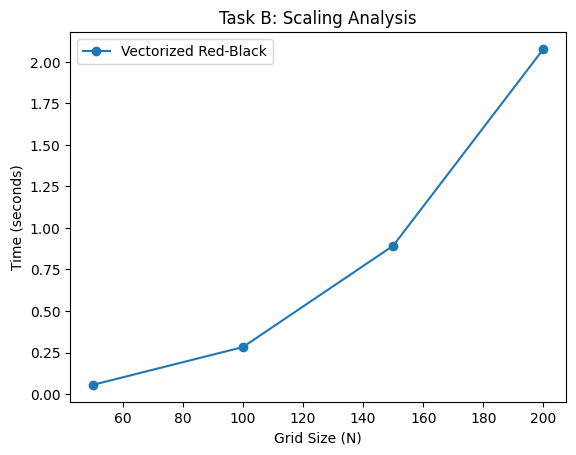

In [ ]:
sizes = [50, 100, 150, 200]
times_loop = []
times_vectorized = []

for N in sizes:
    is_obj = np.zeros((N, N), dtype=bool)
    is_obj[N//2, 0] = True
    c_start = np.zeros((N, N))
    c_start[:, -1] = 1.0
    
    # Benchmark Vectorized
    t0 = time.time()
    solve_sor_vectorized(c_start.copy(), is_obj)
    times_vectorized.append(time.time() - t0)

# Plotting scaling results
plt.plot(sizes, times_vectorized, 'o-', label='Vectorized Red-Black')
# plt.plot(sizes[:len(times_loop)], times_loop, 's-', label='Sequential Loops')
plt.xlabel('Grid Size (N)')
plt.ylabel('Time (seconds)')
plt.title('Scaling Analysis')
plt.legend()
plt.show()